# ML4SCI DeepLense: Detection of Dark Matter Substructure

## Project Overview
This notebook demonstrates a deep learning approach to identify the presence of subhalo dark matter structures in gravitational lensing images. Using Convolutional Neural Networks (CNNs), we automate the differentiation between smooth (no substructure) and substructured lensing systems.

### Methodology
1. **Data Acquisition**: Downloading and extraction of synthetic lensing datasets.
2. **Preprocessing**: Statistical normalization and dtype optimization for high-precision model training.
3. **Architecture**: A modernized CNN featuring LeakyReLU activations and Global Average Pooling.
4. **Transfer Learning**: Experimental evaluation using pre-trained EfficientNetB0 models.

In [ ]:
# Download the dataset from the ML4SCI repository
!wget https://github.com/ML4SCI/ML4SCI_GSoC/raw/main/DeepLense/Domain%20Adaptation/lenses.tgz

# Unzip the dataset into the local environment
!tar -xvzf lenses.tgz

# Verify the extracted directories
!ls -d lenses/*/

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0

print("TensorFlow version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

TensorFlow version: 2.19.0
Eager execution: True


In [10]:
def prepare_lensing_data(base_folder):
    """Loads lensing images and labels from the specified directories."""
    X = []
    y = []

    # Class 0: No Substructure (Smooth Lens)
    no_sub_dir = os.path.join(base_folder, 'no_sub')
    for file in os.listdir(no_sub_dir):
        if file.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(no_sub_dir, file)
            img = Image.open(img_path)
            X.append(np.array(img).squeeze())
            y.append(0)

    # Class 1: Subhalo (Dark Matter Present)
    sub_dir = os.path.join(base_folder, 'sub')
    for file in os.listdir(sub_dir):
        if file.endswith(('.jpg', '.png', '.jpeg')):
            img_path = os.path.join(sub_dir, file)
            img = Image.open(img_path)
            X.append(np.array(img).squeeze())
            y.append(1)

    X = np.array(X)
    if X.ndim == 3:
        X = np.expand_dims(X, axis=-1)
    y = np.array(y)

    return X, y

# Load raw data from filesystem
X_raw, y_raw = prepare_lensing_data('lenses')

# Perform Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Preprocessing: Cast to float32 and normalize image pixel values
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)

min_val = np.min(X_train)
max_val = np.max(X_train)
X_train = (X_train - min_val) / (max_val - min_val + 1e-8)
X_val = (X_val - min_val) / (max_val - min_val + 1e-8)

print(f"Dataset prepared. Training shape: {X_train.shape}")
print(f"Pixel Intensity Range: [{np.min(X_train)}, {np.max(X_train)}]")

Dataset prepared. Training shape: (8000, 150, 150, 1)
Pixel Intensity Range: [0.0, 1.0]


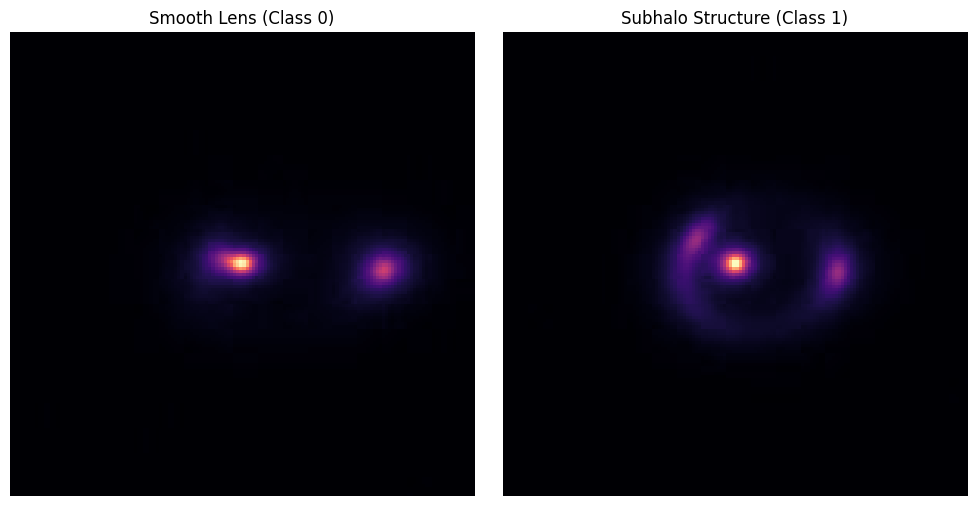

In [11]:
# Visualize Lensing Samples
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Sample from Class 0 (No Substructure)
smooth_sample = X_train[y_train == 0][0].squeeze()
axes[0].imshow(smooth_sample, cmap='magma')
axes[0].set_title("Smooth Lens (Class 0)")
axes[0].axis('off')

# Sample from Class 1 (Subhalo)
subhalo_sample = X_train[y_train == 1][0].squeeze()
axes[1].imshow(subhalo_sample, cmap='magma')
axes[1].set_title("Subhalo Structure (Class 1)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Define Modernized CNN Architecture
model = models.Sequential([
    # Integrated Data Augmentation Block
    layers.RandomFlip("horizontal_and_vertical", input_shape=(150, 150, 1)),
    layers.RandomRotation(0.2),

    # Feature Extraction Stack
    layers.Conv2D(32, (3, 3)),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3)),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3)),
    layers.LeakyReLU(negative_slope=0.1),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Pooling to reduce parameter count and increase generalization
    layers.GlobalAveragePooling2D(),

    # Classification Head
    layers.Dense(64),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 150, 150, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# Training with EarlyStopping and ModelCheckpoint
checkpoint = callbacks.ModelCheckpoint('best_deeplense_model.keras', 
                                       monitor='val_accuracy', 
                                       save_best_only=True, 
                                       mode='max')

early_stop = callbacks.EarlyStopping(monitor='val_loss', 
                                     patience=5, 
                                     restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 60ms/step - accuracy: 0.5449 - loss: 0.6904 - val_accuracy: 0.5060 - val_loss: 0.6979
Epoch 2/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.6273 - loss: 0.6581 - val_accuracy: 0.5290 - val_loss: 0.6848
Epoch 3/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.6750 - loss: 0.6296 - val_accuracy: 0.5060 - val_loss: 0.9197
Epoch 4/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.6924 - loss: 0.6004 - val_accuracy: 0.5070 - val_loss: 1.6329
Epoch 5/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.7161 - loss: 0.5820 - val_accuracy: 0.5090 - val_loss: 0.9787
Epoch 6/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.7349 - loss: 0.5517 - val_accuracy: 0.5215 - val_loss: 0.8820
Epoch 7/25
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.7424 - loss: 0.5394 - val_accuracy: 0.5060 - val_loss: 1.5158


In [14]:
# Experimental: Transfer Learning with EfficientNetB0
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False

model_tl = models.Sequential([
    layers.Input(shape=(150, 150, 1)),
    # Channel Adapter: 1-channel grayscale to 3-channel input
    layers.Conv2D(3, (3, 3), padding='same', activation='relu'),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("Transfer Learning model configured.")

Transfer Learning model configured.
